In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings

from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

In [2]:
def sarima_cv_search(train_data, param_grid, seasonal_period):
    tscv = TimeSeriesSplit(n_splits=2)
    best_score = np.inf
    best_params = None
    for params in ParameterGrid(param_grid):
        mape_scores = []
        for train_idx, val_idx in tscv.split(train_data):
            train_fold = train_data.iloc[train_idx]
            val_fold = train_data.iloc[val_idx]
            try:
                model = SARIMAX(
                    train_fold,
                    order=(params['p'], params['d'], params['q']),
                    seasonal_order=(params['P'], params['D'], params['Q'], seasonal_period),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                forecast = results.forecast(steps=len(val_fold))
                forecast = np.clip(forecast, 0, None)
                mape = mean_absolute_percentage_error(val_fold, forecast)
                mape_scores.append(mape)
            except Exception:
                mape_scores.append(np.inf)
        avg_mape = np.mean(mape_scores)
        if avg_mape < best_score:
            best_score = avg_mape
            best_params = params
    return best_params, best_score

In [3]:
def prophet_cv_search(train_data, param_grid):
    tscv = TimeSeriesSplit(n_splits=3)
    best_score = np.inf
    best_params = None
    train_df = train_data.reset_index().rename(columns={'Invoice_Date': 'ds', 'Quantity': 'y'})
    for params in ParameterGrid(param_grid):
        mape_scores = []
        for train_idx, val_idx in tscv.split(train_df):
            train_fold = train_df.iloc[train_idx]
            val_fold = train_df.iloc[val_idx]
            try:
                model = Prophet(
                    yearly_seasonality=params['yearly_seasonality'],
                    weekly_seasonality=params['weekly_seasonality'],
                    daily_seasonality=False,
                    seasonality_mode=params['seasonality_mode']
                )
                model.fit(train_fold)
                future = pd.DataFrame({'ds': val_fold['ds']})
                forecast = model.predict(future)
                forecasted_sales = forecast['yhat'].clip(lower=0).values
                mape = mean_absolute_percentage_error(val_fold['y'].values, forecasted_sales)
                mape_scores.append(mape)
            except Exception:
                mape_scores.append(np.inf)
        avg_mape = np.mean(mape_scores)
        if avg_mape < best_score:
            best_score = avg_mape
            best_params = params
    return best_params, best_score

In [4]:
def lstm_cv_search(train_data, param_grid):
    tscv = TimeSeriesSplit(n_splits=3)
    best_score = np.inf
    best_params = None
    ts = train_data.values.reshape(-1, 1)
    scaler = MinMaxScaler()
    ts_scaled = scaler.fit_transform(ts)
    for params in ParameterGrid(param_grid):
        mape_scores = []
        for train_idx, val_idx in tscv.split(ts_scaled):
            train_fold = ts_scaled[train_idx]
            val_fold = ts_scaled[val_idx]
            generator = TimeseriesGenerator(train_fold, train_fold, length=params['n_input'], batch_size=1)
            model = Sequential()
            model.add(LSTM(params['units'], activation='relu', input_shape=(params['n_input'], 1)))
            model.add(Dense(1))
            model.compile(optimizer='adam', loss='mse')
            model.fit(generator, epochs=params['epochs'], verbose=0)
            batch = train_fold[-params['n_input']:].reshape((1, params['n_input'], 1))
            val_preds = []
            for i in range(len(val_fold)):
                pred = model.predict(batch, verbose=0)[0]
                val_preds.append(pred[0])
                batch = np.append(batch[:, 1:, :], [[val_fold[i]]], axis=1)
            forecasted_sales = scaler.inverse_transform(np.array(val_preds).reshape(-1, 1)).flatten()
            actual_sales = scaler.inverse_transform(val_fold.reshape(-1, 1)).flatten()
            mape = mean_absolute_percentage_error(actual_sales, forecasted_sales)
            mape_scores.append(mape)
        avg_mape = np.mean(mape_scores)
        if avg_mape < best_score:
            best_score = avg_mape
            best_params = params
    return best_params, best_score

In [5]:
try:
    excel_file = "All_StockCodes_DailyQuantity.xlsx"
    df = pd.read_excel(excel_file)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{excel_file}' was not found. Please ensure it's in the correct directory.")

Data loaded successfully.


In [ ]:
print("\nInitial DataFrame Head:")
print(df.head())
print("\nDataFrame Info:")
print(df.info())

df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'])
df.set_index('Invoice_Date', inplace=True)
unique_products = df['StockCode'].unique()
print(f"\nFound {len(unique_products)} unique products.")
print(f"Missing values in Quantity: {df['Quantity'].isnull().sum()}")

start_date = df.index.min()
split_date = start_date + pd.DateOffset(months=9)


Initial DataFrame Head:
  StockCode Invoice_Date  Quantity
0     10002   2010-12-01        60
1     10002   2010-12-02         1
2     10002   2010-12-03         8
3     10002   2010-12-05         1
4     10002   2010-12-06        25

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276148 entries, 0 to 276147
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   StockCode     276148 non-null  object        
 1   Invoice_Date  276148 non-null  datetime64[ns]
 2   Quantity      276148 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 6.3+ MB
None

Found 3922 unique products.
Missing values in Quantity: 0


In [ ]:
sarima_apes = []
prophet_apes = []
lstm_apes = []

# --- Parameter Grids ---
sarima_param_grid = {
    'p': [0, 1],
    'd': [0, 1],
    'q': [0, 1],
    'P': [0, 1],
    'D': [0, 1],
    'Q': [0, 1],
}
seasonal_period = 7

prophet_param_grid = {
    'yearly_seasonality': [True, False],
    'weekly_seasonality': [True, False],
    'seasonality_mode': ['additive', 'multiplicative']
}


Starting SARIMA model training and forecasting for each product...

Processing product: 10002
10002: train_len=139, test_len=0, train_sum=860
Skipping product 10002 due to insufficient or constant data.

Processing product: 10080
10080: train_len=186, test_len=82, train_sum=146
SARIMA best params: {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 0}, CV MAPE: 0.06


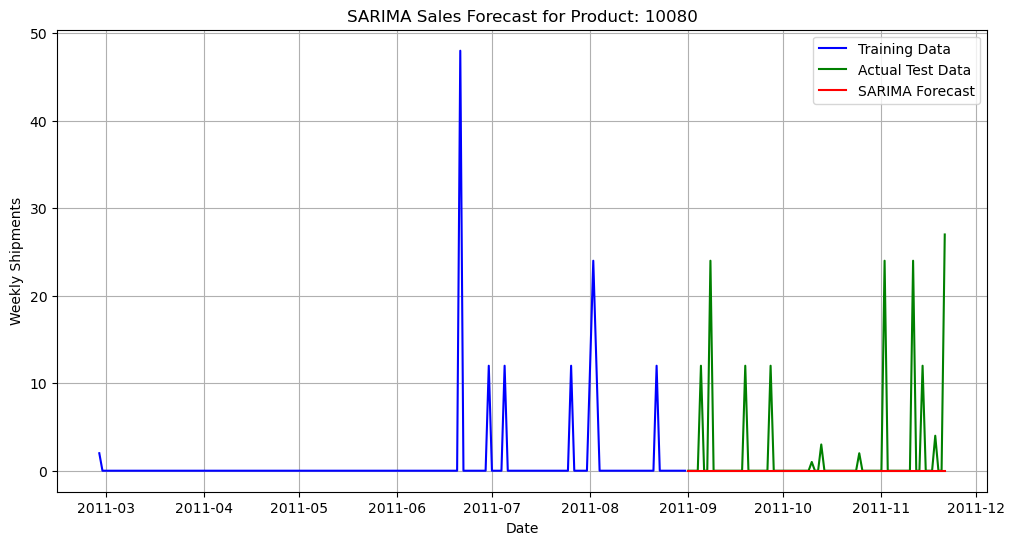


Processing product: 10120
10120: train_len=272, test_len=95, train_sum=117
SARIMA best params: {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 0}, CV MAPE: 0.04


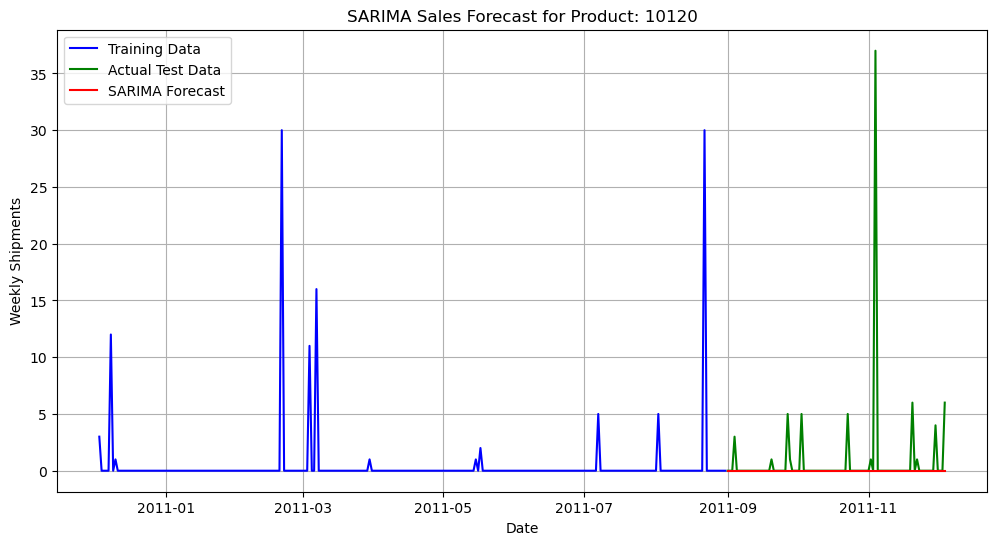


Processing product: 10123C
10123C: train_len=119, test_len=0, train_sum=5
Skipping product 10123C due to insufficient or constant data.

Processing product: 10124A
10124A: train_len=269, test_len=67, train_sum=12
SARIMA best params: {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 0}, CV MAPE: 0.01

Processing product: 10124G
10124G: train_len=273, test_len=67, train_sum=9
SARIMA best params: {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 0}, CV MAPE: 0.01

Processing product: 10125
10125: train_len=274, test_len=100, train_sum=946
SARIMA best params: {'D': 1, 'P': 1, 'Q': 0, 'd': 1, 'p': 1, 'q': 1}, CV MAPE: 0.16

Processing product: 10133
10133: train_len=274, test_len=7, train_sum=2649
SARIMA best params: {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 1}, CV MAPE: 0.42

Processing product: 10135
10135: train_len=274, test_len=99, train_sum=1840
SARIMA best params: {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 1}, CV MAPE: 0.20

Processing product: 11001
11001: train_len=274, test_len=97

In [9]:
try:
    print("\nStarting SARIMA model training and forecasting for each product...")

    for stock_code in unique_products:
        print(f"\nProcessing product: {stock_code}")
        product_data = df[df['StockCode'] == stock_code]
        product_ts = product_data['Quantity'].groupby(product_data.index).sum()
        all_weeks = pd.date_range(start=product_ts.index.min(), end=product_ts.index.max(), freq='D')
        product_ts = product_ts.reindex(all_weeks, fill_value=0)
        product_ts = product_ts.sort_index()
        train_data = product_ts[product_ts.index < split_date]
        test_data = product_ts[product_ts.index >= split_date]
        print(f"{stock_code}: train_len={len(train_data)}, test_len={len(test_data)}, train_sum={train_data.sum()}")  # Debug

        # Skip products with insufficient or constant data
        if len(train_data) < 15 or len(test_data) < 4 or train_data.nunique() <= 1 or train_data.sum() == 0:
            print(f"Skipping product {stock_code} due to insufficient or constant data.")
            continue

        # --- SARIMA ---
        try:
            best_params, best_score = sarima_cv_search(train_data, sarima_param_grid, seasonal_period)
            print(f"SARIMA best params: {best_params}, CV MAPE: {best_score:.2f}")
            model = SARIMAX(
                train_data,
                order=(best_params['p'], best_params['d'], best_params['q']),
                seasonal_order=(best_params['P'], best_params['D'], best_params['Q'], seasonal_period),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = model.fit(disp=False)
            forecast = results.forecast(steps=len(test_data))
            forecasted_sales = pd.Series(np.clip(forecast, 0, None), index=test_data.index)
            ape = (abs(test_data - forecasted_sales) / (test_data + 1e-8)) * 100
            sarima_apes.extend(ape.tolist())
            if len(sarima_apes) < 3 * len(test_data):
                plt.figure(figsize=(12, 6))
                plt.plot(train_data.index, train_data, label='Training Data', color='blue')
                plt.plot(test_data.index, test_data, label='Actual Test Data', color='green')
                plt.plot(test_data.index, forecasted_sales, label='SARIMA Forecast', color='red')
                plt.title(f'SARIMA Sales Forecast for Product: {stock_code}')
                plt.xlabel('Date')
                plt.ylabel('Weekly Shipments')
                plt.legend()
                plt.grid(True)
                plt.show()
        except Exception as e:
            print(f"SARIMA failed for {stock_code}: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Starting Prophet model training and forecasting for each product...

Processing product: 10002
10002: train_len=139, test_len=0, train_sum=860
Skipping product 10002 due to insufficient data.

Processing product: 10080
10080: train_len=186, test_len=82, train_sum=146


18:56:48 - cmdstanpy - INFO - Chain [1] start processing
18:56:49 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE for 10080: 3924457772.75%


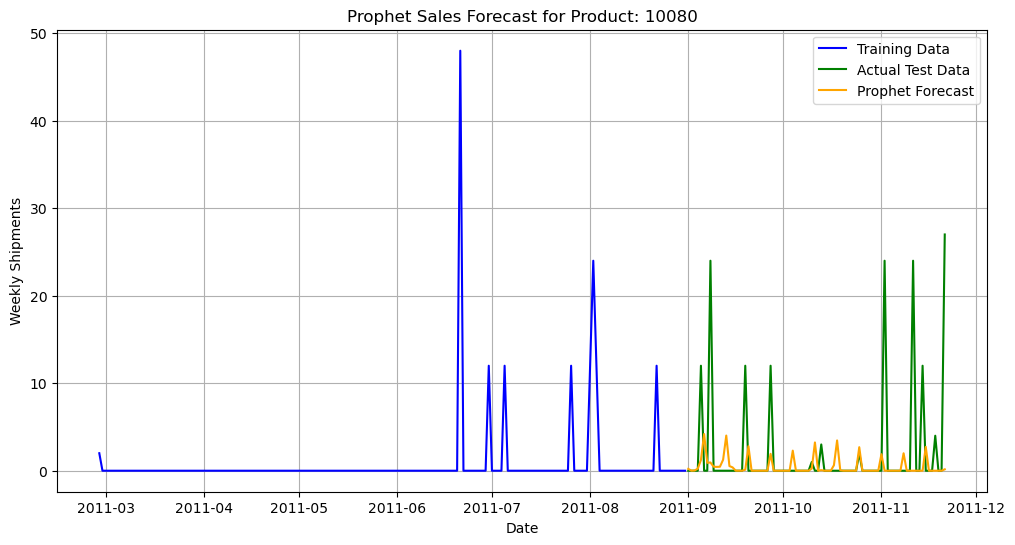


Processing product: 10120
10120: train_len=272, test_len=95, train_sum=117


18:56:50 - cmdstanpy - INFO - Chain [1] start processing
18:56:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE for 10120: 210885598.26%


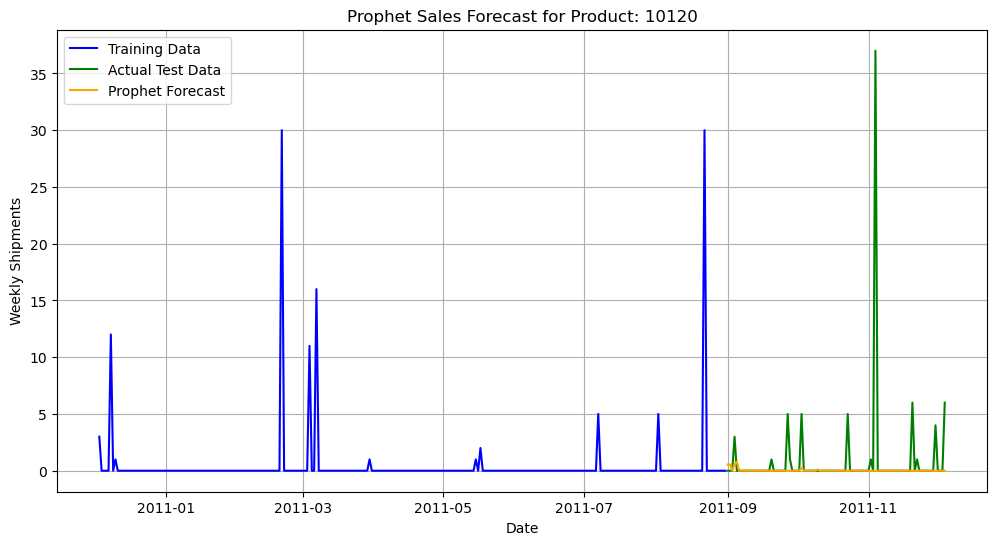


Processing product: 10123C
10123C: train_len=119, test_len=0, train_sum=5
Skipping product 10123C due to insufficient data.

Processing product: 10124A
10124A: train_len=269, test_len=67, train_sum=12


18:56:51 - cmdstanpy - INFO - Chain [1] start processing
18:56:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE for 10124A: 1.49%

Processing product: 10124G
10124G: train_len=273, test_len=67, train_sum=9


18:56:51 - cmdstanpy - INFO - Chain [1] start processing
18:56:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE for 10124G: 2.99%

Processing product: 10125
10125: train_len=274, test_len=100, train_sum=946


...

Prophet MAPE for S: 18451524.39%

Processing product: gift_0001_10
gift_0001_10: train_len=178, test_len=99, train_sum=8


19:38:55 - cmdstanpy - INFO - Chain [1] start processing
19:38:55 - cmdstanpy - INFO - Chain [1] done processing
19:38:55 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
19:38:55 - cmdstanpy - INFO - Chain [1] start processing
19:38:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE for gift_0001_10: 243653931003.54%

Processing product: gift_0001_20
gift_0001_20: train_len=239, test_len=61, train_sum=9


19:38:58 - cmdstanpy - INFO - Chain [1] start processing
19:38:58 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE for gift_0001_20: 1601088.06%

Processing product: gift_0001_30
gift_0001_30: train_len=239, test_len=2, train_sum=6
Skipping product gift_0001_30 due to insufficient data.

Processing product: gift_0001_40
gift_0001_40: train_len=220, test_len=0, train_sum=3
Skipping product gift_0001_40 due to insufficient data.

Processing product: gift_0001_50
gift_0001_50: train_len=190, test_len=0, train_sum=4
Skipping product gift_0001_50 due to insufficient data.

Processing product: m
m: train_len=1, test_len=0, train_sum=1
Skipping product m due to insufficient data.


In [10]:
try:
    print("\nStarting Prophet model training and forecasting for each product...")

    for stock_code in unique_products:
        print(f"\nProcessing product: {stock_code}")
        product_data = df[df['StockCode'] == stock_code]
        product_ts = product_data['Quantity'].groupby(product_data.index).sum()
        all_weeks = pd.date_range(start=product_ts.index.min(), end=product_ts.index.max(), freq='D')
        product_ts = product_ts.reindex(all_weeks, fill_value=0)
        product_ts = product_ts.sort_index()
        train_data = product_ts[product_ts.index < split_date]
        test_data = product_ts[product_ts.index >= split_date]
        print(f"{stock_code}: train_len={len(train_data)}, test_len={len(test_data)}, train_sum={train_data.sum()}")  # Debug

        if len(train_data) < 15 or len(test_data) < 4 or train_data.nunique() <= 1 or train_data.sum() == 0:
            print(f"Skipping product {stock_code} due to insufficient data.")
            continue

        # --- Prophet without hyperparameter tuning ---
        try:
            prophet_df = pd.DataFrame({'ds': train_data.index, 'y': train_data.values})
            model = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode='additive',
                changepoint_prior_scale=0.01
            )
            model.fit(prophet_df)
            future = pd.DataFrame({'ds': test_data.index})
            forecast = model.predict(future)
            forecasted_sales = forecast['yhat'].clip(lower=0).values
            ape = (abs(test_data.values - forecasted_sales) / (test_data.values + 1e-8)) * 100
            prophet_apes.extend(ape.tolist())
            product_mape = np.mean(ape)
            print(f"Prophet MAPE for {stock_code}: {product_mape:.2f}%")
            if len(prophet_apes) < 3 * len(test_data):
                plt.figure(figsize=(12, 6))
                plt.plot(train_data.index, train_data, label='Training Data', color='blue')
                plt.plot(test_data.index, test_data, label='Actual Test Data', color='green')
                plt.plot(test_data.index, forecasted_sales, label='Prophet Forecast', color='orange')
                plt.title(f'Prophet Sales Forecast for Product: {stock_code}')
                plt.xlabel('Date')
                plt.ylabel('Weekly Shipments')
                plt.legend()
                plt.grid(True)
                plt.show()
        except Exception as e:
            print(f"Prophet failed for {stock_code}: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [12]:
sarima_apes

[0.0,
 0.0,
 0.0,
 0.0,
 99.99999991666667,
 0.0,
 0.0,
 99.99999995833333,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999991666667,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999991666667,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999900000002,
 0.0,
 0.0,
 99.99999966666667,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.9999995,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999995833333,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999995833333,
 0.0,
 0.0,
 99.99999991666667,
 0.0,
 0.0,
 0.0,
 99.99999975,
 0.0,
 0.0,
 99.99999996296296,
 0.0,
 0.0,
 0.0,
 99.99999966666667,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999900000002,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999980000001,
 99.99999900000002,
 0.0,
 0.0,
 0.0,
 0.0,
 99.99999980000001,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 

In [13]:
prophet_apes

[2106432047.8131704,
 0.0,
 269386525.2456724,
 2333707502.633799,
 89.77742140073983,
 41908817382.410774,
 9040116769.743473,
 96.0736197229736,
 4590663610.061002,
 4370718054.769344,
 4566816886.209361,
 12534474540.452375,
 40172901697.0391,
 5323488618.993247,
 3807202066.457057,
 0.0,
 0.0,
 0.0,
 99.03010161685177,
 28027604644.322258,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 83.902658284515,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 22931827074.051636,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 75.95840653902758,
 32313878663.198025,
 0.0,
 97.84531654507266,
 0.0,
 0.0,
 0.0,
 6254135511.905223,
 34616957488.23714,
 500099730.34629786,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 34.477466237845285,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 18906416969.433014,
 99.99999995833333,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 19965969088.308147,
 0.0,
 0.0,
 99.99999995833333,
 0.0,
 0.0,
 99.99999991666667,
 27263921417.63525,
 0.0,
 0.0,
 99.99999975,
 0.0,
 0.0,
 99.40879325720867,
 5416880779.687533,
 5662679316.377581,
 0.0,


In [14]:
# --- Model Evaluation ---
def print_results(model_name, apes):
    if apes:
        mean_ape = np.mean(apes)
        print(f"{model_name} Mean APE across all products: {mean_ape:.2f}%")
    else:
        print(f"{model_name} could not be evaluated.")

print("\n--- Model Performance Comparison ---")
print_results("SARIMA", sarima_apes)
print_results("Prophet", prophet_apes)

mean_apes = {
    "SARIMA": np.mean(sarima_apes) if sarima_apes else np.inf,
    "Prophet": np.mean(prophet_apes) if prophet_apes else np.inf,
}
best_model = min(mean_apes, key=mean_apes.get)
print(f"\nBest model for future sales prediction: {best_model}")


--- Model Performance Comparison ---
SARIMA Mean APE across all products: 1898388810.95%
Prophet Mean APE across all products: 74720699193.59%

Best model for future sales prediction: SARIMA
